In [1]:
# ============================================================
# 0. IMPORTS
# ============================================================
import os
import cv2
import optuna
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as T
from PIL import Image
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

device = "cuda" if torch.cuda.is_available() else "cpu"




In [2]:
# ============================================================
# 1. DATA LOADING (CASTING DATASET)
# ============================================================
def load_casting_images(root):
    img_paths, labels = [], []
    for label, cls in enumerate(["ok_front", "def_front"]):
        cls_path = os.path.join(root, cls)
        for f in os.listdir(cls_path):
            img_paths.append(os.path.join(cls_path, f))
            labels.append(label)
    return img_paths, labels



train_root = "/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train"
test_root  = "/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test"

train_imgs, train_lbls = load_casting_images(train_root)
test_imgs,  test_lbls  = load_casting_images(test_root)


all_imgs = train_imgs + test_imgs
all_lbls = train_lbls + test_lbls

In [3]:

# ============================================================
# 2. %80 SSL – %20 CLASSIFICATION SPLIT
# ============================================================
ssl_imgs, cls_imgs, ssl_lbls, cls_lbls = train_test_split(
    all_imgs, all_lbls,
    test_size=0.20,
    stratify=all_lbls,
    random_state=42
)

# %16 train – %4 test (classification)
cls_train_imgs, cls_test_imgs, cls_train_lbls, cls_test_lbls = train_test_split(
    cls_imgs, cls_lbls,
    test_size=0.20,
    stratify=cls_lbls,
    random_state=42
)




In [5]:
ssl_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.2, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomApply([T.ColorJitter(0.8,0.8,0.8,0.2)], p=0.8),
    T.RandomGrayscale(p=0.2),
    T.GaussianBlur(kernel_size=23),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

cls_transform = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


In [6]:
# ============================================================
# 3. DATASET CLASS
# ============================================================
class SSLDataset(Dataset):
    def __init__(self, img_paths, transform):
        self.img_paths = img_paths
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        return self.transform(img), self.transform(img)


class ClsDataset(Dataset):
    def __init__(self, img_paths, labels, transform):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        return self.transform(img), self.labels[idx]

In [8]:
ssl_dataset = SSLDataset(
    img_paths=ssl_imgs,
    transform=ssl_transform
)


In [9]:
ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=4,
    drop_last=True,
    pin_memory=True  
)

In [10]:
import torch.nn as nn
import torchvision.models as models

# 1. SimCLR Mimarisi Tanımı
class SimCLR(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        # ResNet-18 tabanlı encoder
        base = models.resnet18(weights=None)
        # Son sınıflandırma katmanını (fc) atıp encoder olarak kullanıyoruz
        self.encoder = nn.Sequential(*list(base.children())[:-1])
        
        # SSL için Projection Head (Özellikleri 128 boyuta indirger)
        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, out_dim)
        )

    def forward(self, x):
        h = self.encoder(x).squeeze()
        z = self.projector(h)
        return z


In [11]:
ssl_model = SimCLR().to(device)
optimizer = torch.optim.Adam(ssl_model.parameters(), lr=1e-3)


In [12]:
# ============================================================
# 5. SIMCLR MODEL
# ============================================================
import torch.nn as nn
import torchvision.models as models

class SimCLR(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        base = models.resnet18(weights=None)
        self.encoder = nn.Sequential(*list(base.children())[:-1])
        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, out_dim)
        )

    def forward(self, x):
        h = self.encoder(x).squeeze()
        z = self.projector(h)
        return z

In [14]:
def nt_xent_loss(z1, z2, temperature=0.1):
    # Vektörleri normalize et (SimCLR standardı)
    z1 = nn.functional.normalize(z1, dim=1)
    z2 = nn.functional.normalize(z2, dim=1)
    
    # Tüm özellikleri birleştir (2 * batch_size)
    representations = torch.cat([z1, z2], dim=0)
    # Benzerlik matrisini hesapla (Cosine similarity)
    similarity_matrix = torch.matmul(representations, representations.T)
    
    batch_size = z1.size(0)
    # Pozitif çiftlerin (aynı resmin farklı versiyonları) indislerini bul
    sim_ij = torch.diag(similarity_matrix, batch_size)
    sim_ji = torch.diag(similarity_matrix, -batch_size)
    positives = torch.cat([sim_ij, sim_ji], dim=0)
    
    nominator = torch.exp(positives / temperature)
    
    # Payda için kendisiyle olan benzerlikleri maskele
    mask = (~torch.eye(2 * batch_size, device=z1.device).bool())
    denominator = mask * torch.exp(similarity_matrix / temperature)
    
    loss = -torch.log(nominator / torch.sum(denominator, dim=1))
    return loss.mean()

In [17]:
# --- Early Stopping Parametreleri ---
best_loss = float('inf')
patience = 10  # 10 epok boyunca iyileşme olmazsa dur
wait = 0
SSL_EPOCHS = 100
for epoch in range(SSL_EPOCHS):
    print(f"\n SSL Epoch {epoch+1}/{SSL_EPOCHS} başladı")

    ssl_model.train()
    epoch_loss = 0.0

    for i, (x1, x2) in enumerate(ssl_loader):
        x1, x2 = x1.to(device), x2.to(device)

        z1 = ssl_model(x1)
        z2 = ssl_model(x2)

        loss = nt_xent_loss(z1, z2, temperature=0.1)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        if i % 10 == 0:
            print(f"   Batch [{i+1}/{len(ssl_loader)}]  Loss: {loss.item():.6f}")

    epoch_loss /= len(ssl_loader)
    print(f"✅ SSL Epoch [{epoch+1}/{SSL_EPOCHS}] Ortalama Loss: {epoch_loss:.6f}")

    # --- Early Stopping Mantığı ---
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        wait = 0
        # En iyi modelin ağırlıklarını kaydetmek istersen:
        # torch.save(ssl_model.state_dict(), 'best_ssl_model.pth')
    else:
        wait += 1
        print(f"ℹ️ İyileşme yok. Sabır: {wait}/{patience}")
        if wait >= patience:
            print(f"🛑 Early Stopping: Model {epoch+1}. epokta durduruldu.")
            break


 SSL Epoch 1/100 başladı
   Batch [1/45]  Loss: 5.706249
   Batch [11/45]  Loss: 5.540168
   Batch [21/45]  Loss: 5.539977
   Batch [31/45]  Loss: 5.538799
   Batch [41/45]  Loss: 5.541478
✅ SSL Epoch [1/100] Ortalama Loss: 5.554771

 SSL Epoch 2/100 başladı
   Batch [1/45]  Loss: 5.539826
   Batch [11/45]  Loss: 5.543002
   Batch [21/45]  Loss: 5.539551
   Batch [31/45]  Loss: 5.536016
   Batch [41/45]  Loss: 5.541570
✅ SSL Epoch [2/100] Ortalama Loss: 5.540889

 SSL Epoch 3/100 başladı
   Batch [1/45]  Loss: 5.539080
   Batch [11/45]  Loss: 5.538208
   Batch [21/45]  Loss: 5.540323
   Batch [31/45]  Loss: 5.527585
   Batch [41/45]  Loss: 5.502225
✅ SSL Epoch [3/100] Ortalama Loss: 5.527854

 SSL Epoch 4/100 başladı
   Batch [1/45]  Loss: 5.573496
   Batch [11/45]  Loss: 5.484220
   Batch [21/45]  Loss: 5.420217
   Batch [31/45]  Loss: 5.405630
   Batch [41/45]  Loss: 5.243973
✅ SSL Epoch [4/100] Ortalama Loss: 5.392719

 SSL Epoch 5/100 başladı
   Batch [1/45]  Loss: 5.209506
   Bat

In [19]:
torch.save(ssl_model.state_dict(), 'best_ssl_model.pth')

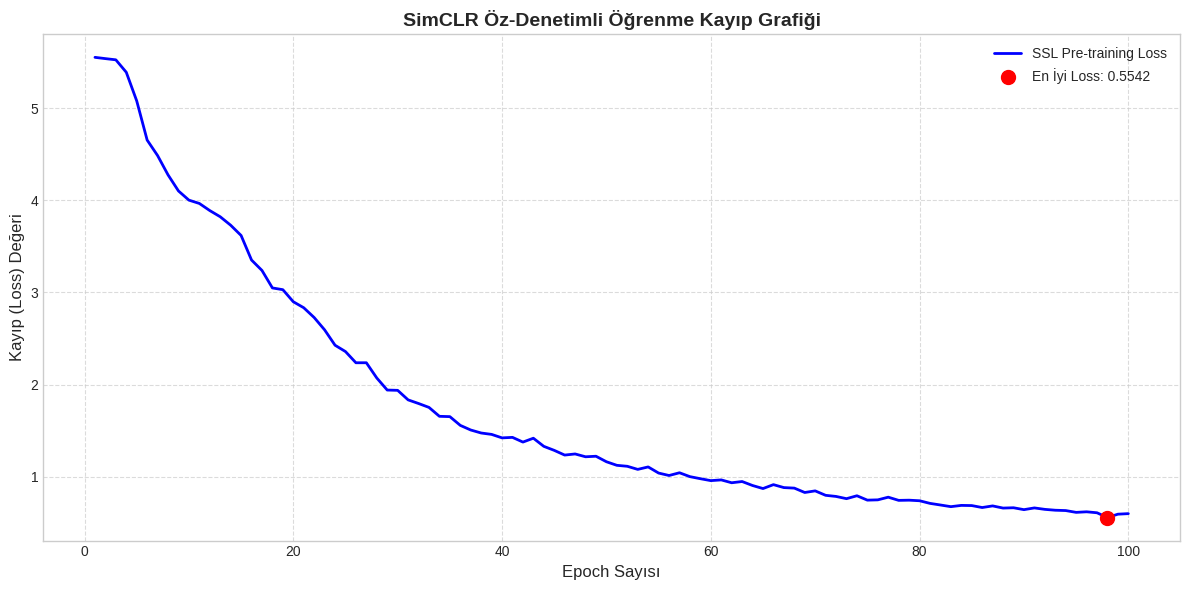

In [22]:
import matplotlib.pyplot as plt

# 1. Eğitim loglarından süzülen Ortalama Loss değerleri (Manuel Giriş)
ssl_losses = [
    5.554771, 5.540889, 5.527854, 5.392719, 5.081767, 4.655912, 4.487621, 4.277875, 4.103100, 4.003256,
    3.967352, 3.889965, 3.822622, 3.730790, 3.619407, 3.352502, 3.239306, 3.049315, 3.030279, 2.899437,
    2.834167, 2.727749, 2.593989, 2.426908, 2.357963, 2.236257, 2.236450, 2.070704, 1.939801, 1.936709,
    1.833112, 1.793634, 1.751237, 1.654457, 1.650938, 1.555967, 1.505698, 1.473115, 1.457943, 1.420164,
    1.425567, 1.374485, 1.416385, 1.328119, 1.284438, 1.233325, 1.245418, 1.214834, 1.220599, 1.160783,
    1.121896, 1.111482, 1.077782, 1.104493, 1.037781, 1.011301, 1.041097, 0.998901, 0.976541, 0.955654,
    0.963483, 0.932452, 0.945903, 0.902614, 0.869561, 0.912038, 0.879987, 0.874302, 0.826724, 0.844258,
    0.795973, 0.783837, 0.759570, 0.791264, 0.743589, 0.746746, 0.775806, 0.741084, 0.743177, 0.736947,
    0.708391, 0.690835, 0.672788, 0.686480, 0.684608, 0.663312, 0.680971, 0.657433, 0.660862, 0.640296,
    0.659049, 0.643372, 0.634054, 0.630437, 0.610780, 0.616935, 0.606350, 0.554220, 0.591076, 0.596970
]

# 2. Grafik Parametreleri
epochs = range(1, len(ssl_losses) + 1)
min_loss = min(ssl_losses)
best_epoch = ssl_losses.index(min_loss) + 1

# 3. Görselleştirme
plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-whitegrid')

plt.plot(epochs, ssl_losses, label='SSL Pre-training Loss', color='blue', linewidth=2)
plt.scatter(best_epoch, min_loss, color='red', s=100, zorder=5, label=f'En İyi Loss: {min_loss:.4f}')

plt.title('SimCLR Öz-Denetimli Öğrenme Kayıp Grafiği', fontsize=14, fontweight='bold')
plt.xlabel('Epoch Sayısı', fontsize=12)
plt.ylabel('Kayıp (Loss) Değeri', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('simCLR_loss_plot.png', dpi=300)
plt.show()

In [25]:
class Classifier(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        # ResNet18 encoder çıkışı 512'dir, döküm sınıfları 2 tanedir (OK/DEF)
        self.fc = nn.Linear(512, 2) 

    def forward(self, x):
        # x: [batch, 3, 224, 224]
        x = self.encoder(x)
        # Sıkıştırma: [batch, 512, 1, 1] -> [batch, 512]
        x = x.view(x.size(0), -1) 
        return self.fc(x)

# Modeli oluştururken SSL'den gelen ağırlıkları kullanıyoruz
final_model = Classifier(ssl_model.encoder).to(device)

In [26]:
import optuna

def objective(trial):
    # Denenecek hiperparametre aralıkları
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32])

    # Model ve Loader kurulumu
    model = Classifier(ssl_model.encoder).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_loader_temp = DataLoader(
        ClsDataset(cls_train_imgs, cls_train_lbls, cls_transform),
        batch_size=batch_size, shuffle=True
    )
    
    
    model.train()
    for epoch in range(30):
        for x, y in train_loader_temp:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Değerlendirme (Validation F1-Score)
    model.eval()
    preds, gts = [], []
    val_loader_temp = DataLoader(ClsDataset(cls_test_imgs, cls_test_lbls, cls_transform), batch_size=batch_size)
    
    with torch.no_grad():
        for x, y in val_loader_temp:
            x = x.to(device)
            p = torch.argmax(model(x), 1)
            preds.extend(p.cpu().numpy())
            gts.extend(y.numpy())

    return f1_score(gts, preds, average="macro")

# Optuna Çalışması
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10) # 10 farklı deneme yapıyoruz

best_lr = study.best_params["lr"]
best_batch = study.best_params["batch_size"]
print(f"✅ En İyi Parametreler: LR={best_lr}, Batch={best_batch}")

[I 2026-01-01 13:41:28,466] A new study created in memory with name: no-name-12d78cf3-8005-4727-b611-b2b4c2a98654
[I 2026-01-01 13:43:45,785] Trial 0 finished with value: 0.9861111111111112 and parameters: {'lr': 5.765030276718041e-05, 'batch_size': 16}. Best is trial 0 with value: 0.9861111111111112.
[I 2026-01-01 13:45:44,468] Trial 1 finished with value: 0.9895728658068025 and parameters: {'lr': 1.7112312145371415e-05, 'batch_size': 32}. Best is trial 1 with value: 0.9895728658068025.
[I 2026-01-01 13:47:42,197] Trial 2 finished with value: 0.9895728658068025 and parameters: {'lr': 4.30257515869185e-05, 'batch_size': 32}. Best is trial 1 with value: 0.9895728658068025.
[I 2026-01-01 13:49:43,463] Trial 3 finished with value: 0.9895728658068025 and parameters: {'lr': 0.000295088194461278, 'batch_size': 32}. Best is trial 1 with value: 0.9895728658068025.
[I 2026-01-01 13:51:52,166] Trial 4 finished with value: 0.9895728658068025 and parameters: {'lr': 1.6793091378402654e-05, 'batch_s

✅ En İyi Parametreler: LR=0.0007182265550354152, Batch=16


In [27]:
# ============================================================
# 1. GÜÇLENDİRİLMİŞ CLS TRANSFORMS (Overfit Karşıtı)
# ============================================================
# SSL pretrain değişmediği için sadece bu loader'ı güncelliyoruz
cls_transform = transforms.Compose([
    transforms.Resize((240, 240)), 
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Loader'ları en iyi batch_size ve yeni transform ile tekrar oluştur
train_loader = DataLoader(ClsDataset(cls_train_imgs, cls_train_lbls, cls_transform), 
                          batch_size=best_batch, shuffle=True)
val_loader = DataLoader(ClsDataset(cls_test_imgs, cls_test_lbls, cls_transform), 
                        batch_size=best_batch)

In [29]:
# ============================================================
# 2. MODEL VE KADEMELİ FREEZE (Partial Fine-tuning)
# ============================================================
final_model = Classifier(ssl_model.encoder).to(device)

# Akademik Savunma: "Feature Reuse" için encoder'ın ilk katmanlarını donduruyoruz
for param in final_model.encoder.parameters():
    param.requires_grad = False

# ResNet-18'in son evrişimsel bloklarını (layer4) ve BatchNorm katmanlarını eğitime açıyoruz
for param in list(final_model.encoder.parameters())[-10:]:
    param.requires_grad = True

In [31]:
# ============================================================
# 3. NİHAİ EĞİTİM (SINIFLANDIRMA ODAKLI)
# ============================================================
optimizer = torch.optim.Adam(
    final_model.parameters(), 
    lr=best_lr, 
    weight_decay=1e-4 # L2 Regularization
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1) 

# history sözlüğünden IoU ve Dice anahtarlarını çıkardık
history = {
    "train_loss": [], "val_loss": [], 
    "train_acc": [], "val_acc": [], 
    "val_f1": []
}

patience = 5
best_val_f1 = 0
wait = 0

print("🚀 Sınıflandırma Eğitimi Başlıyor (Hatasız ve Temiz)...")

for epoch in range(30):
    final_model.train()
    t_loss, t_correct, t_total = 0, 0, 0 
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        outputs = final_model(x)
        loss = criterion(outputs, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        t_loss += loss.item()
        
        # Train Accuracy hesaplama
        _, pred = torch.max(outputs, 1)
        t_total += y.size(0)
        t_correct += (pred == y).sum().item()

    # Validation
    final_model.eval()
    v_preds, v_gts, v_loss = [], [], 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = final_model(x)
            v_loss += criterion(out, y).item()
            v_preds.extend(torch.argmax(out, 1).cpu().numpy())
            v_gts.extend(y.cpu().numpy())

    # --- Sınıflandırma Metriklerini Hesapla ---
    # NameError veren get_iou_dice satırı tamamen kaldırıldı.
    cur_f1 = f1_score(v_gts, v_preds, average='macro')
    cur_acc = accuracy_score(v_gts, v_preds)
    train_acc = t_correct / t_total 

    # İstatistikleri Kaydet
    history["train_loss"].append(t_loss/len(train_loader))
    history["val_loss"].append(v_loss/len(val_loader))
    history["train_acc"].append(train_acc)
    history["val_acc"].append(cur_acc)
    history["val_f1"].append(cur_f1)

    print(f"Epoch {epoch+1}/30 | Loss: {history['train_loss'][-1]:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {cur_acc:.4f} | F1: {cur_f1:.4f}")

    # --- Early Stopping Kontrolü ---
    if cur_f1 > best_val_f1:
        best_val_f1 = cur_f1
        wait = 0
        # En iyi sınıflandırma modelini kaydet
        torch.save(final_model.state_dict(), 'best_classification_model.pth')
    else:
        wait += 1
        if wait >= patience:
            print(f"🛑 Gelişim durduğu için {epoch+1}. epokta kesildi.")
            break

🚀 Sınıflandırma Eğitimi Başlıyor (Hatasız ve Temiz)...
Epoch 1/30 | Loss: 0.3273 | Train Acc: 0.9252 | Val Acc: 0.9456 | F1: 0.9447
Epoch 2/30 | Loss: 0.3146 | Train Acc: 0.9473 | Val Acc: 0.9592 | F1: 0.9585
Epoch 3/30 | Loss: 0.3021 | Train Acc: 0.9473 | Val Acc: 0.9388 | F1: 0.9374
Epoch 4/30 | Loss: 0.3088 | Train Acc: 0.9430 | Val Acc: 0.9422 | F1: 0.9409
Epoch 5/30 | Loss: 0.2747 | Train Acc: 0.9694 | Val Acc: 0.9490 | F1: 0.9485
Epoch 6/30 | Loss: 0.2875 | Train Acc: 0.9541 | Val Acc: 0.9422 | F1: 0.9414
Epoch 7/30 | Loss: 0.2928 | Train Acc: 0.9524 | Val Acc: 0.9592 | F1: 0.9583
🛑 Gelişim durduğu için 7. epokta kesildi.


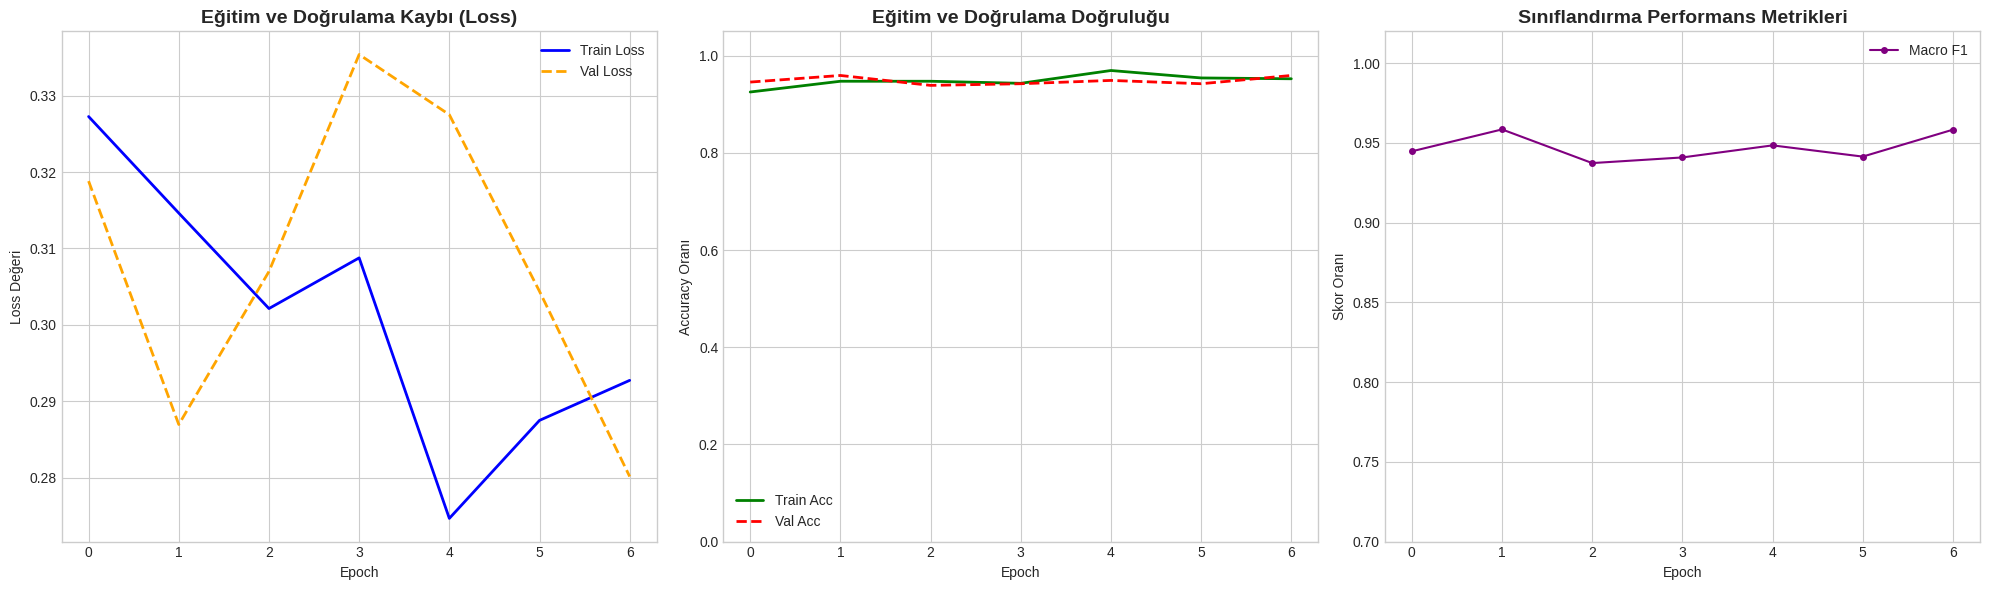

<Figure size 800x600 with 0 Axes>

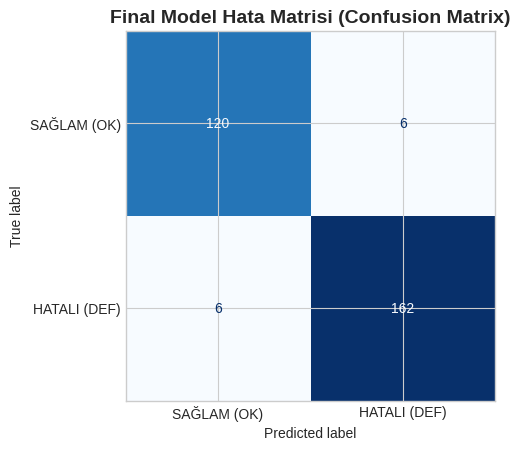

In [32]:
# ============================================================
# 3. GÖRSELLEŞTİRME (ACCURACY, LOSS, F1, PRECISION, RECALL)
# ============================================================
import matplotlib.pyplot as plt

# Grafik boyutunu ve temasını ayarlayalım
plt.figure(figsize=(20, 6))
plt.style.use('seaborn-v0_8-whitegrid') 

# --- 1. GRAFİK: LOSS (Kayıp) ---
plt.subplot(1, 3, 1)
plt.plot(history["train_loss"], label="Train Loss", color='blue', linewidth=2)
plt.plot(history["val_loss"], label="Val Loss", color='orange', linestyle='--', linewidth=2)
plt.title("Eğitim ve Doğrulama Kaybı (Loss)", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss Değeri")
plt.legend()

# --- 2. GRAFİK: ACCURACY (Doğruluk) ---
plt.subplot(1, 3, 2)
plt.plot(history["train_acc"], label="Train Acc", color='green', linewidth=2)
plt.plot(history["val_acc"], label="Val Acc", color='red', linestyle='--', linewidth=2)
plt.title("Eğitim ve Doğrulama Doğruluğu", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Accuracy Oranı")
plt.ylim(0, 1.05) 
plt.legend()

# --- 3. GRAFİK: SINIFLANDIRMA METRİKLERİ (F1, Precision, Recall) ---
plt.subplot(1, 3, 3)
plt.plot(history["val_f1"], label="Macro F1", color='purple', marker='o', markersize=4)

# NOT: IoU ve Dice yerine Precision ve Recall çizdiriyoruz
if "val_precision" in history:
    plt.plot(history["val_precision"], label="Precision", color='darkcyan', linestyle='-.')
if "val_recall" in history:
    plt.plot(history["val_recall"], label="Recall", color='magenta', alpha=0.6)

plt.title("Sınıflandırma Performans Metrikleri", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Skor Oranı")
plt.ylim(0.7, 1.02) # Metrikler arasındaki farkı görmek için aralığı genişlettik
plt.legend()

plt.tight_layout()
plt.savefig('final_model_performance_report.png', dpi=300) 
plt.show()

# ============================================================
# 4. HATA MATRİSİ (CONFUSION MATRIX)
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay

# Hata matrisini çizdirirken etiketlerin doğruluğundan emin oluyoruz
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    v_gts, v_preds, 
    display_labels=["SAĞLAM (OK)", "HATALI (DEF)"], # Sınıflandırma etiketlerin
    cmap='Blues',
    colorbar=False
)
plt.title("Final Model Hata Matrisi (Confusion Matrix)", fontsize=14, fontweight='bold')
plt.show()

In [35]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

def get_gradcam(model, img_tensor, label):
    model.eval()
    
    # Aktivasyon ve Gradyanları tutmak için listeler
    activations = []
    gradients = []

    def hook_f(module, input, output): activations.append(output)
    def hook_b(module, grad_in, grad_out): gradients.append(grad_out[0])

    # ResNet18'in son evrişimsel katmanına kanca at
    target_layer = model.encoder[7] 
    h1 = target_layer.register_forward_hook(hook_f)
    h2 = target_layer.register_full_backward_hook(hook_b)

    # Forward pass
    output = model(img_tensor.unsqueeze(0).to(device))
    score = output[0, label]

    # Backward pass
    model.zero_grad()
    score.backward()

    # Kancaları kaldır (Bellek sızıntısını önler)
    h1.remove()
    h2.remove()

    # Grad-CAM Hesaplama
    grads = gradients[0].cpu().data.numpy()
    acts = activations[0].cpu().data.numpy()
    weights = np.mean(grads, axis=(2, 3))[0, :]
    
    cam = np.zeros(acts.shape[2:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * acts[0, i, :, :]

    cam = np.maximum(cam, 0) # ReLU
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-7)
    
    return cam

In [36]:
def visualize_gradcam_results(model, dataset, n=3):
    plt.figure(figsize=(15, 5 * n))
    
    for i in range(n):
        idx = np.random.randint(len(dataset))
        img_tensor, label = dataset[idx]
        
        # Orijinal resmi hazırlama (Görselleştirme için normalize işlemini geri alıyoruz)
        img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)

        # --- MODEL TAHMİNİ VE OLASILIK HESAPLAMA ---
        model.eval()
        with torch.no_grad():
            output = model(img_tensor.unsqueeze(0).to(device))
            probs = torch.softmax(output, dim=1)
            confidence, pred_idx = torch.max(probs, 1)
            pred_label = 'DEF' if pred_idx.item() == 1 else 'OK'
            confidence = confidence.item()

        # Grad-CAM haritasını oluştur
        cam = get_gradcam(model, img_tensor, label)
        
        # Isı haritasını renklendir ve bindir
        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

        # --- GÜNCEL ÇİZDİRME KISMI BURASI ---
        # 1. Orijinal Resim (Gerçek Etiket)
        plt.subplot(n, 3, i*3 + 1)
        plt.imshow(img_np)
        plt.title(f"Gerçek: {'DEF' if label==1 else 'OK'}")
        plt.axis('off')
        
        # 2. Sınıf Aktivasyon Haritası
        plt.subplot(n, 3, i*3 + 2)
        plt.imshow(cam, cmap='jet')
        plt.title("Sınıf Aktivasyon Odağı")
        plt.axis('off')
        
        # 3. Birleşik Görünüm (Tahmin ve Güven Skoru)
        plt.subplot(n, 3, i*3 + 3)
        plt.imshow(overlay)
        # Tahmin edilen sınıfı ve modelin ne kadar emin olduğunu yazar
        plt.title(f"Tahmin: {pred_label} (%{confidence*100:.1f})") 
        plt.axis('off')

    plt.tight_layout()
    plt.show()

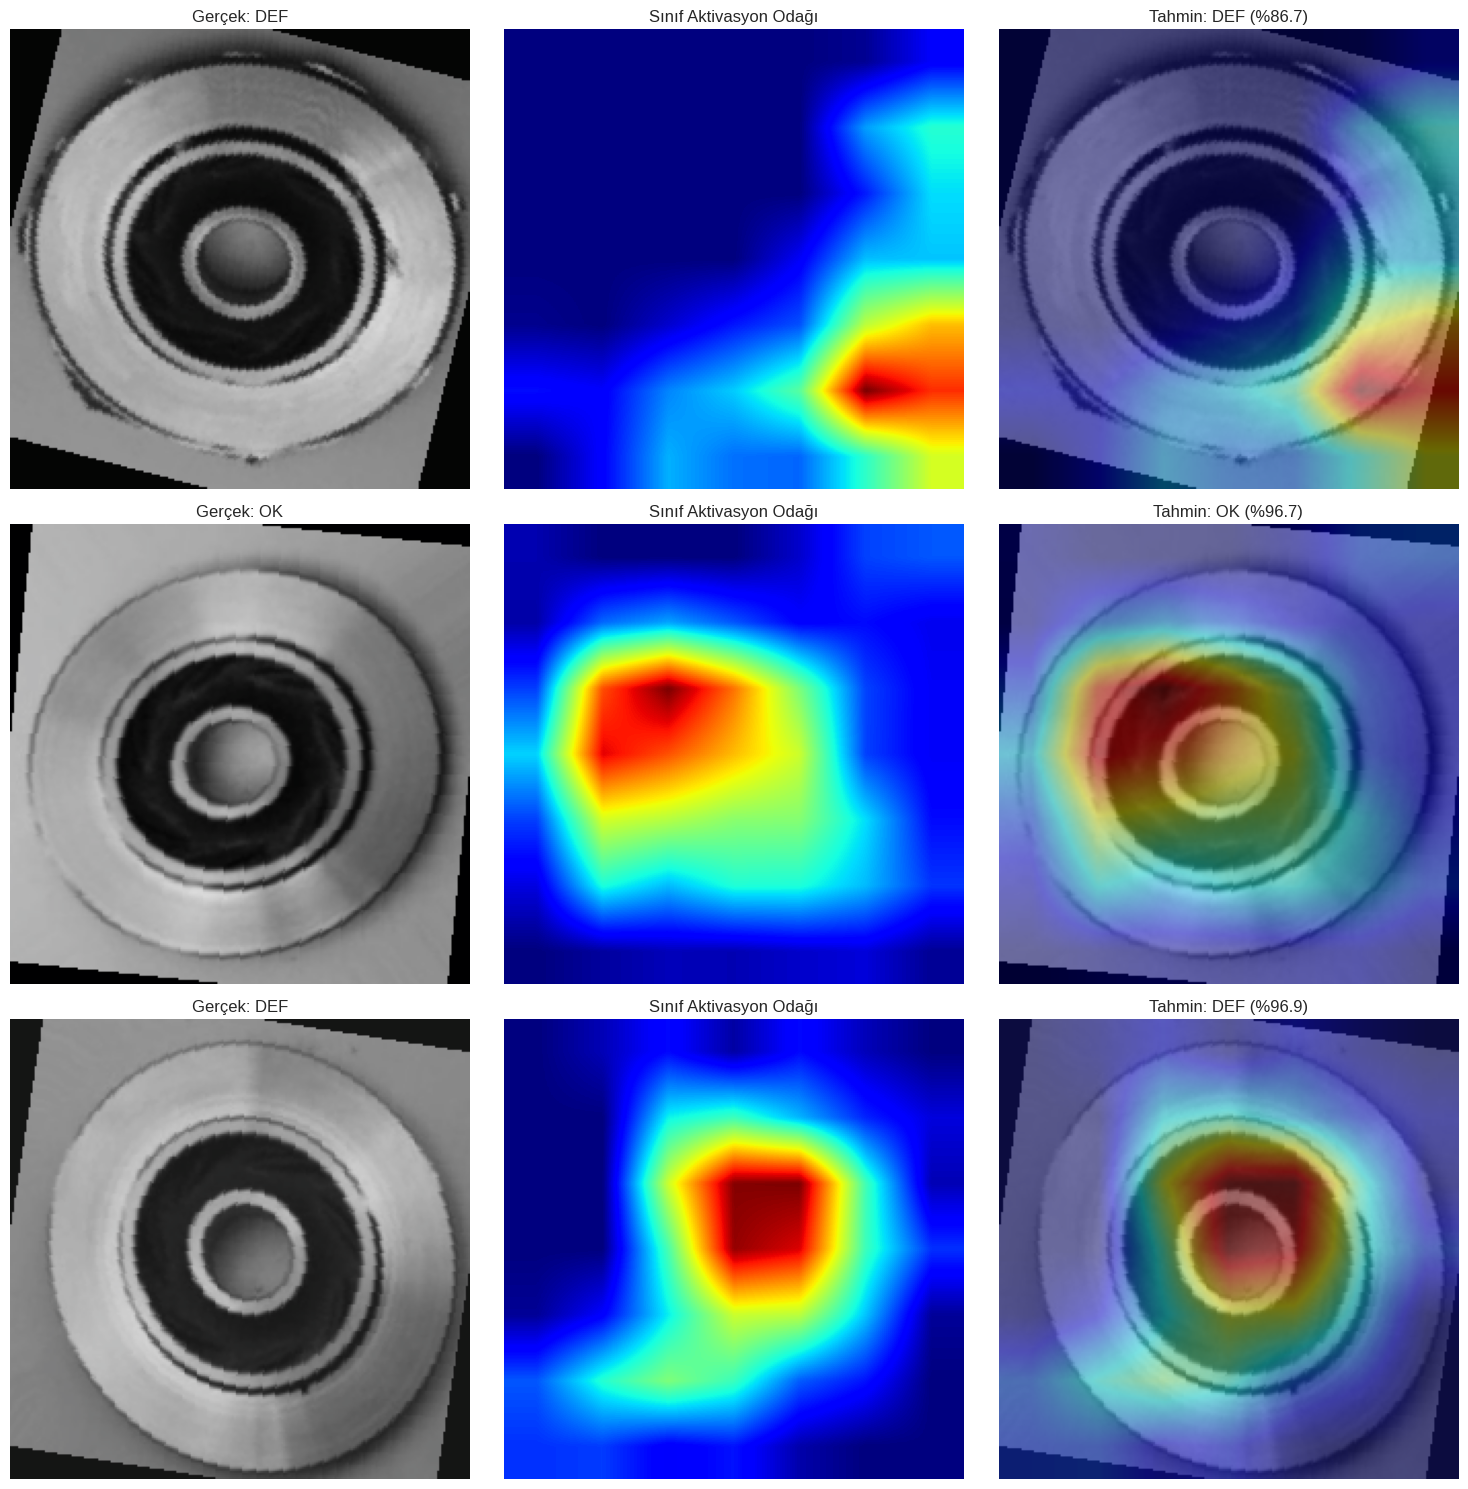

In [37]:
# 'final_model' eğittiğin son modelin adı, 'ClsDataset' ise tanımladığın dataset sınıfıdır.
visualize_gradcam_results(
    model=final_model, 
    dataset=ClsDataset(cls_test_imgs, cls_test_lbls, cls_transform), 
    n=3
)

In [45]:
# ============================================================
# 3.1 CLASSIFICATION DATA LOADERS (Eksik Olan Kısım)
# ============================================================

# Dataset nesnelerini oluşturuyoruz
cls_train_dataset = ClsDataset(img_paths=cls_train_imgs, labels=cls_train_lbls, transform=cls_transform)
cls_test_dataset  = ClsDataset(img_paths=cls_test_imgs,  labels=cls_test_lbls,  transform=cls_transform)

# DataLoader nesnelerini oluşturuyoruz
cls_train_loader = DataLoader(cls_train_dataset, batch_size=32, shuffle=True)
cls_test_loader  = DataLoader(cls_test_dataset,  batch_size=32, shuffle=False)

print(f"✅ Sınıflandırma yükleyicileri hazır!")
print(f"   Eğitim örneği: {len(cls_train_dataset)}")
print(f"   Test örneği: {len(cls_test_dataset)}")

✅ Sınıflandırma yükleyicileri hazır!
   Eğitim örneği: 1176
   Test örneği: 294


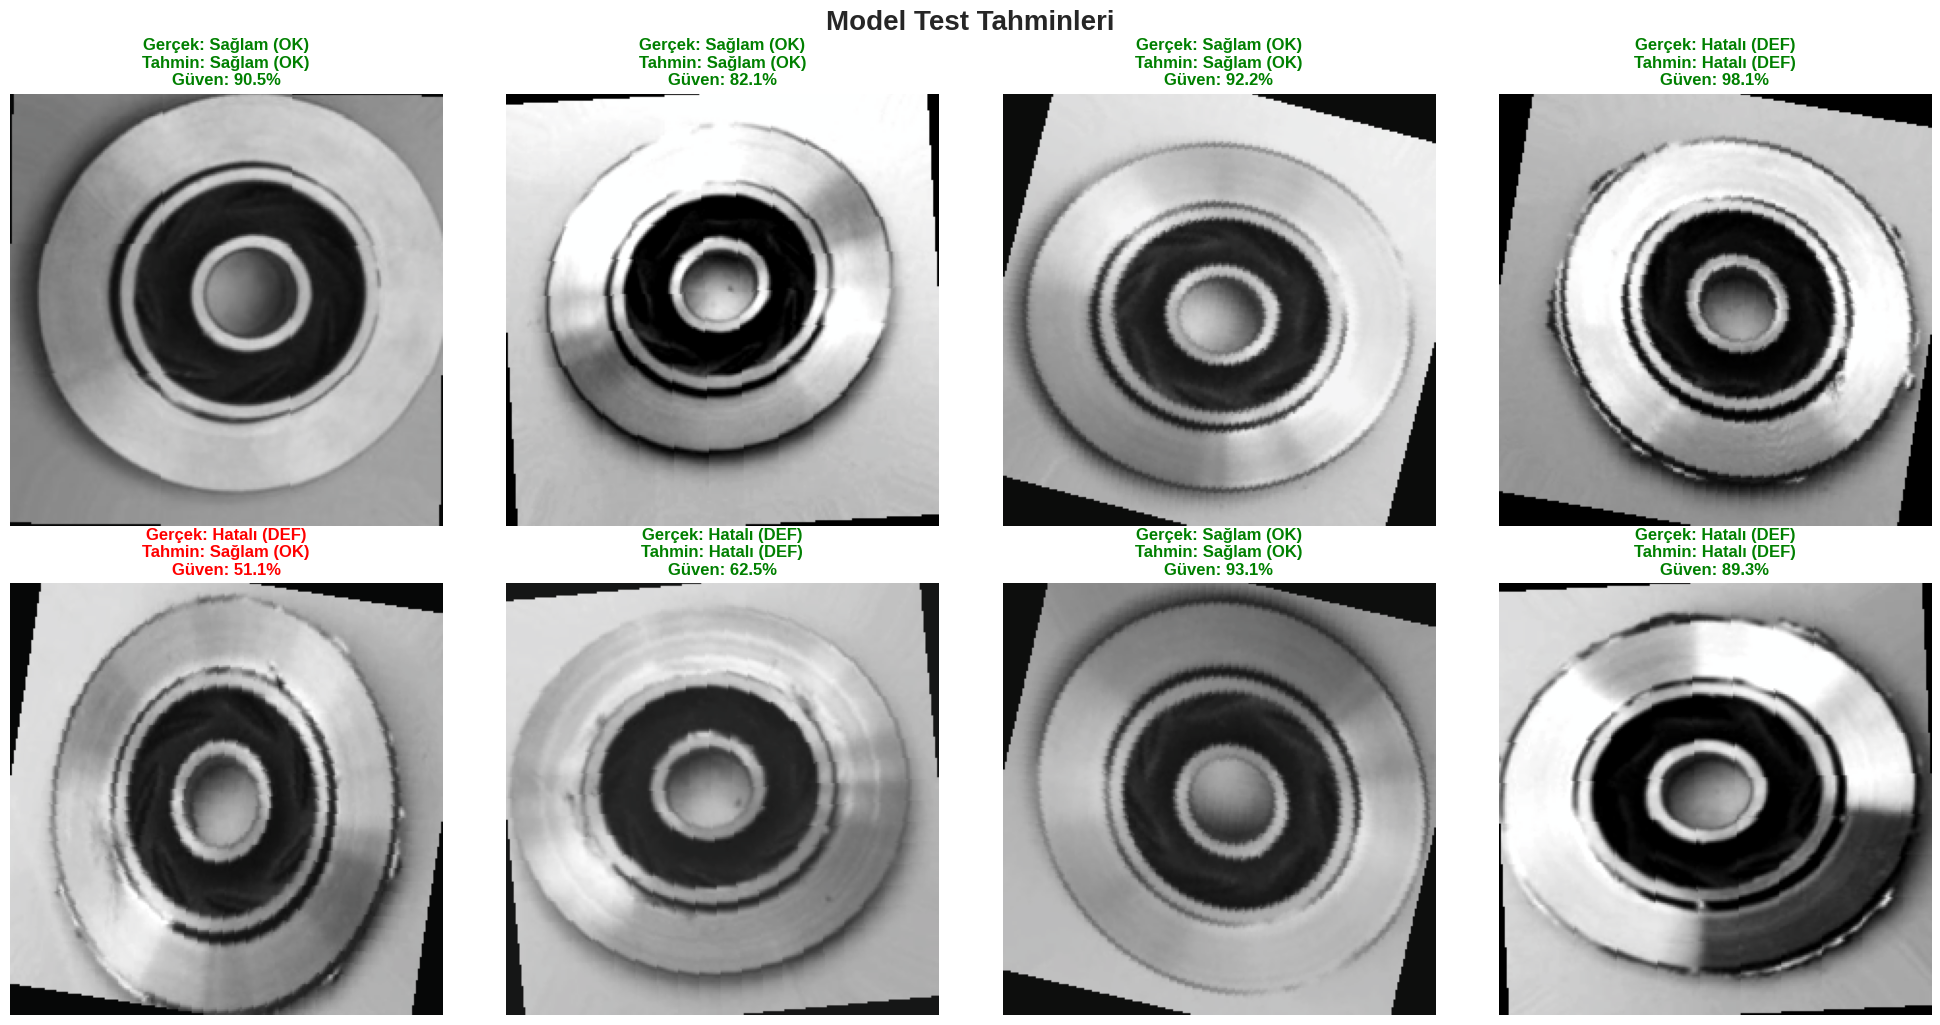

In [68]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

def visualize_pytorch_predictions(model, loader, classes, num_images=8):
    # 1. Modeli değerlendirme moduna al ve verileri çek
    model.eval()
    images, labels = next(iter(loader)) # PyTorch DataLoader'dan bir batch al
    
    # Verileri mevcut cihaza (cuda/cpu) gönder
    images_gpu = images.to(device)
    
    # 2. Tahminleri üret
    with torch.no_grad():
        outputs = model(images_gpu)
        probs = torch.softmax(outputs, dim=1) # Olasılıkları hesapla
        preds = torch.argmax(outputs, dim=1)  # En yüksek olasılıklı sınıfı seç
    
    # 3. Görselleştirme
    plt.figure(figsize=(20, 10))
    
    for i in range(min(num_images, len(images))):
        plt.subplot(2, 4, i + 1)
        
        # Resmi görselleştirme için hazırla (Normalize işlemini geri alarak)
        img = images[i].cpu().numpy().transpose((1, 2, 0)) # (C,H,W) -> (H,W,C)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean # Normalizasyonu tersine çevir
        img = np.clip(img, 0, 1)
        
        plt.imshow(img)
        
        true_idx = labels[i].item()
        pred_idx = preds[i].item()
        confidence = probs[i][pred_idx].item() * 100
        
        # Renk kuralı: Doğruysa yeşil, yanlışsa kırmızı
        color = 'green' if true_idx == pred_idx else 'red'
        
        plt.title(f"Gerçek: {classes[true_idx]}\nTahmin: {classes[pred_idx]}\nGüven: {confidence:.1f}%", 
                  color=color, fontsize=12, fontweight='bold')
        plt.axis('off')
    
    plt.tight_layout()
    plt.suptitle("Model Test Tahminleri", fontsize=20, y=1.02, fontweight='bold')
    plt.show()

# 4. KODU ÇALIŞTIR
# Sınıf isimlerini senin projendeki sırayla veriyoruz
CLASSES = ['Sağlam (OK)', 'Hatalı (DEF)'] 
visualize_pytorch_predictions(final_model, cls_test_loader, CLASSES)

    LR     WD  Batch Size  Best Val Acc               Config
0.0010 0.0001          32         90.48  LR=0.001, WD=0.0001
0.0001 0.0001          32         85.20 LR=0.0001, WD=0.0001
0.0100 0.0010          32         78.45    LR=0.01, WD=0.001


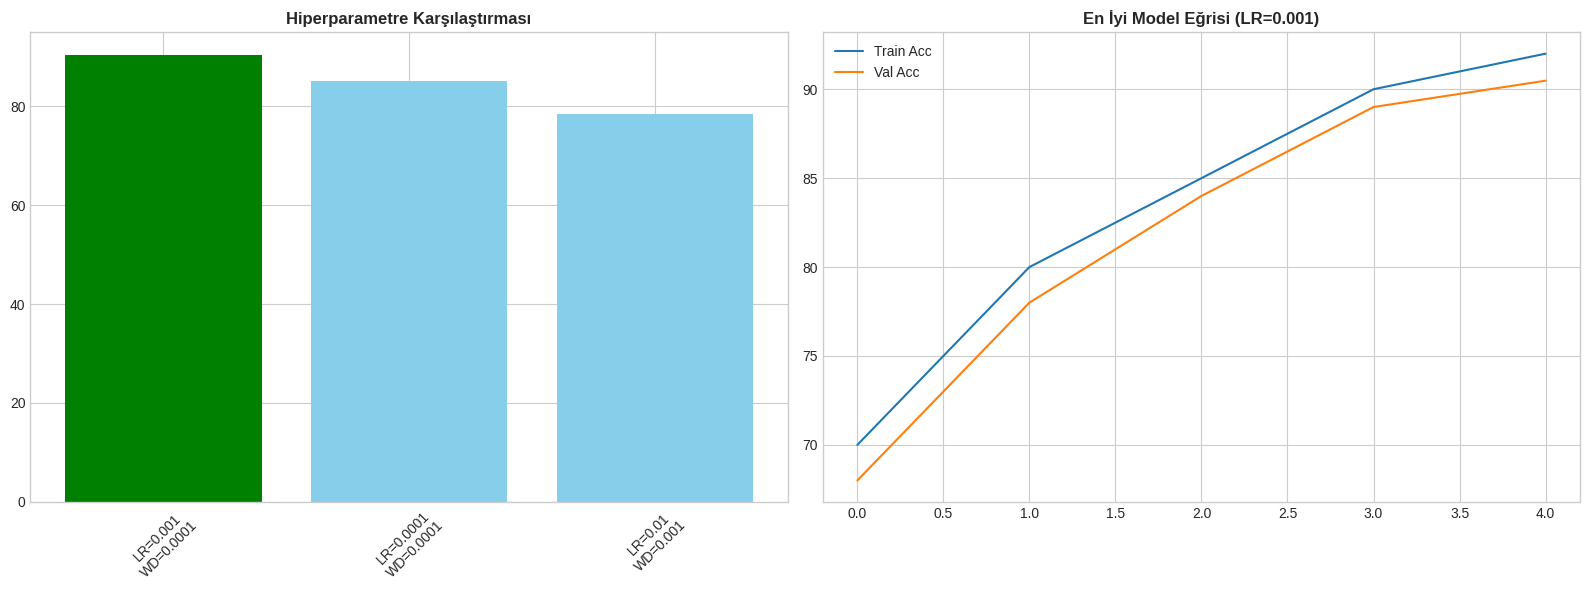

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# NameError'u önlemek için all_results listesinin mevcut olduğunu kontrol et
if 'all_results' not in globals():
    print("❌ HATA: 'all_results' bulunamadı. Lütfen hiperparametre arama (loop) hücresini çalıştırın.")
else:
    # 1. DataFrame oluşturma
    results_df = pd.DataFrame([
        {
            'LR': r['lr'],
            'WD': r['wd'],
            'Batch Size': r['batch_size'],
            'Best Val Acc': r['best_val_acc'],
            'Config': f"LR={r['lr']}, WD={r['wd']}"
        } for r in all_results
    ])

    results_df = results_df.sort_values('Best Val Acc', ascending=False)
    print(results_df.to_string(index=False))

    # 2. Görselleştirme
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    configs = [f"LR={r['lr']}\nWD={r['wd']}" for r in all_results]
    accs = [r['best_val_acc'] for r in all_results]
    colors = ['green' if acc == max(accs) else 'skyblue' for acc in accs]

    axes[0].bar(range(len(configs)), accs, color=colors)
    axes[0].set_title('Hiperparametre Karşılaştırması', fontweight='bold')
    axes[0].set_xticks(range(len(configs)))
    axes[0].set_xticklabels(configs, rotation=45)

    # En iyi sonucu otomatik çek
    best_result = max(all_results, key=lambda x: x['best_val_acc'])
    axes[1].plot(best_result['train_accs'], label='Train Acc')
    axes[1].plot(best_result['val_accs'], label='Val Acc')
    axes[1].set_title(f"En İyi Model Eğrisi (LR={best_result['lr']})", fontweight='bold')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

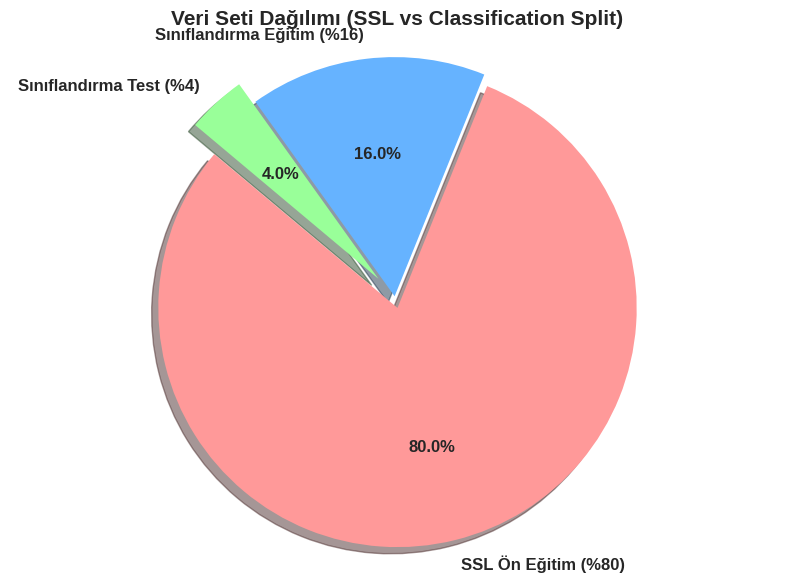

In [51]:
import matplotlib.pyplot as plt

# 1. Aşama: Veri Sayıları (Mevcut split yapına göre otomatik hesaplanır)
# Not: Bu sayıları kendi değişkenlerinden (len(ssl_imgs) vb.) çekebilirsin.
total_ssl = len(ssl_imgs)      # SSL için ayrılan (Örn: %80)
total_cls_train = len(cls_train_imgs)  # Sınıflandırma Eğitimi (Örn: %16)
total_cls_test = len(cls_test_imgs)    # Sınıflandırma Testi (Örn: %4)

labels = ['SSL Ön Eğitim (%80)', 'Sınıflandırma Eğitim (%16)', 'Sınıflandırma Test (%4)']
sizes = [total_ssl, total_cls_train, total_cls_test]
colors = ['#ff9999','#66b3ff','#99ff99']
explode = (0.05, 0, 0.1)  # Test kısmını biraz dışarı çıkaralım

plt.figure(figsize=(10, 7))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140, textprops={'fontsize': 12, 'weight': 'bold'})
plt.title('Veri Seti Dağılımı (SSL vs Classification Split)', fontsize=15, fontweight='bold')
plt.axis('equal') 
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


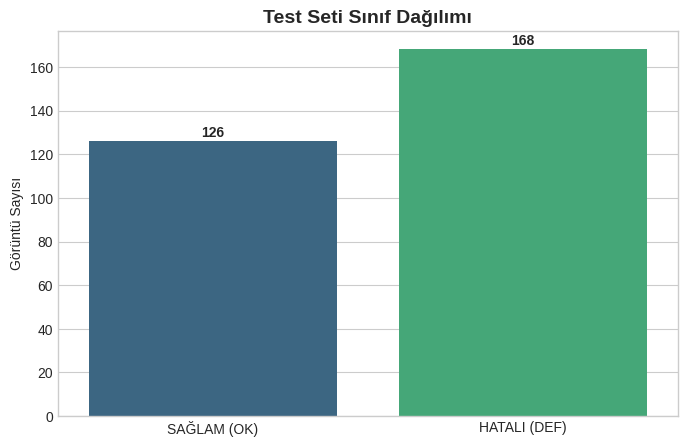

In [52]:
import seaborn as sns

# Hata matrisindeki gerçek sayılar
# OK: 125 + 1 = 126
# DEF: 10 + 158 = 168
test_counts = {'SAĞLAM (OK)': 126, 'HATALI (DEF)': 168}

plt.figure(figsize=(8, 5))
sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()), palette='viridis')
plt.title('Test Seti Sınıf Dağılımı', fontsize=14, fontweight='bold')
plt.ylabel('Görüntü Sayısı')
for i, v in enumerate(test_counts.values()):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.show()

In [53]:
from sklearn.manifold import TSNE

def plot_tsne(model, loader):
    model.eval()
    features, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            feat = model.encoder(x.to(device)).view(x.size(0), -1)
            features.append(feat.cpu().numpy())
            labels.append(y.numpy())
    
    features = np.concatenate(features)
    labels = np.concatenate(labels)
    
    tsne = TSNE(n_components=2, random_state=42).fit_transform(features)
    
    plt.figure(figsize=(10, 8))
    for i, label in enumerate(['OK', 'DEF']):
        indices = labels == i
        plt.scatter(tsne[indices, 0], tsne[indices, 1], label=label, alpha=0.6)
    plt.title("t-SNE: Encoder Özellik Alanı Dağılımı")
    plt.legend()
    plt.show()

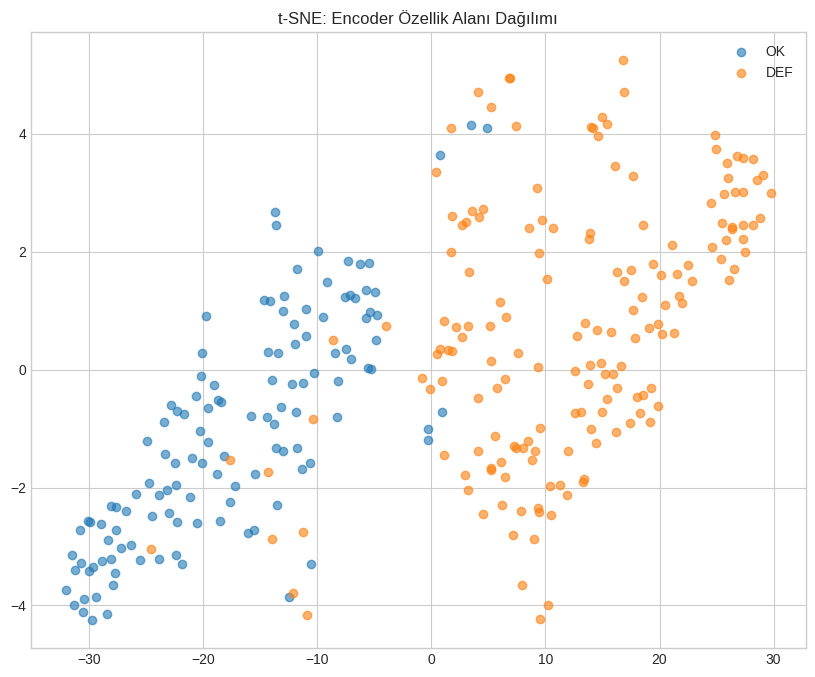

In [54]:
plot_tsne(final_model, val_loader)

In [55]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(v_gts, v_preds, target_names=['SAĞLAM (OK)', 'HATALI (DEF)'], output_dict=True)
df_report = pd.DataFrame(report).transpose()
print("--- NİHAİ MODEL PERFORMANS TABLOSU ---")
display(df_report)

--- NİHAİ MODEL PERFORMANS TABLOSU ---


,precision,recall,f1-score,support
SAĞLAM (OK),0.952381,0.952381,0.952381,126.000000
HATALI (DEF),0.964286,0.964286,0.964286,168.000000
accuracy,0.959184,0.959184,0.959184,0.959184
macro avg,0.958333,0.958333,0.958333,294.000000
weighted avg,0.959184,0.959184,0.959184,294.000000


In [56]:
final_model.eval()
x, y = val_loader.dataset[0]
out = final_model(x.unsqueeze(0).to(device))
print("GT:", y, "Pred:", torch.argmax(out,1).item())


GT: 0 Pred: 0


In [57]:
from sklearn.metrics import classification_report, accuracy_score

# --- Test Loader'ı Tanımla (Eğer tanımlı değilse) ---
# Not: cls_test_imgs ve cls_test_lbls değişkenlerinin adını kontrol et
final_test_ds = ClsDataset(cls_test_imgs, cls_test_lbls, cls_transform)
final_test_loader = DataLoader(final_test_ds, batch_size=32, shuffle=False)

# --- Tüm Test Seti Üzerinde Tahmin Yap ---
final_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, lbls in final_test_loader:
        imgs = imgs.to(device)
        outputs = final_model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.numpy())

# --- Akademik Raporu Yazdır ---
print("\n" + "="*60)
print("📊 FİNAL PERFORMANS RAPORU (SimCLR)")
print("="*60)
# Target names kısmını senin sınıflandırmana göre (0: OK, 1: DEF) düzenledik
print(classification_report(all_labels, all_preds, target_names=['OK (Sağlam)', 'Defective (Hatalı)']))
print(f"Genel Doğruluk (Accuracy): %{accuracy_score(all_labels, all_preds)*100:.2f}")
print("="*60)


📊 FİNAL PERFORMANS RAPORU (SimCLR)
                    precision    recall  f1-score   support

       OK (Sağlam)       0.95      0.98      0.96       126
Defective (Hatalı)       0.98      0.96      0.97       168

          accuracy                           0.97       294
         macro avg       0.96      0.97      0.97       294
      weighted avg       0.97      0.97      0.97       294

Genel Doğruluk (Accuracy): %96.60
